# Geometric coupling and structural fragility

This notebook reproduces the primary exposure analysis and Main Figure 1. It (1) contrasts centroid distance, surface distance, pairwise geometric coupling $F_{ij}$ and cumulative realized exposure $F^*$; (2) quantifies the information in $F^*$ beyond scalar distance; (3) estimates fire-specific destruction $F_{50}$ values; and (4) identifies the exposure range in which damage remains partial rather than becoming total loss.

**Manuscript link:** Results, *Structure-to-structure exposure thresholds*. Model-selection tests, alternative calibrations and bootstrap diagnostics belong in `extended_data/ED02_fragility_sensitivity.ipynb`. Network thresholding begins in notebook 04.

In [1]:
import json
import subprocess
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, cwd.parent.parent]
PACKAGE_ROOT = next(
    (path for path in candidates
     if (path / 'data').exists() and (path / 'src').exists()
     and (path / 'notebooks').exists()),
    None,
)
if PACKAGE_ROOT is None:
    raise RuntimeError('Run from the reproduction-package root or a notebook subdirectory')
PROJECT_ROOT = PACKAGE_ROOT
sys.path.insert(0, str(PACKAGE_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.analysis.fragility import (
    FIRES, distance_equivalence_table, distance_outcome_summary,
    fit_curves_by_fire, fit_distance_calibration, partial_damage_summary,
    prepare_distance_comparison,
)
from src.analysis.population_audit import sha256
from src.viz.figure1 import (
    plot_distance_comparison, plot_fragility, plot_partial_damage,
)
from src.viz.style import apply_style

apply_style()
DATA = PROJECT_ROOT / 'data'
RESULTS = PACKAGE_ROOT / 'results'
FIGURES = PACKAGE_ROOT / 'figures' / 'main'
SOURCE_DATA = PACKAGE_ROOT / 'data' / 'derived'
for directory in [RESULTS, FIGURES, SOURCE_DATA]:
    directory.mkdir(parents=True, exist_ok=True)
N_BOOT = 200
SEED = 0

## Population gate

Notebook 01 will not run if the canonical analysis table differs from the checksummed input validated in notebook 00.

In [2]:
manifest = json.loads((RESULTS / 'analysis_manifest.json').read_text())
analysis_path = DATA / 'analysis.parquet'
assert sha256(analysis_path) == manifest['inputs']['analysis']['sha256']
analysis = pd.read_parquet(analysis_path)
exposed = analysis[analysis.exposed.eq(1)].copy()
assert len(analysis) == 28_208 and len(exposed) == 25_127
display(pd.crosstab(exposed.outcome, exposed.fire, margins=True))
print(f'{len(analysis):,} assessed structures; {len(exposed):,} with F* > 0')

fire,EATON,PALISADES,All
outcome,,,
destroyed,8557,6488,15045
no_damage,5094,3144,8238
partial,944,900,1844
All,14595,10532,25127


28,208 assessed structures; 25,127 with F* > 0


## Measuring structural separation

The conceptual row applies CCD, SSD and pairwise geometric coupling to the same observed Eaton building pair. A fourth panel then sums $F_{ij}$ across multiple burned visible neighbors to illustrate cumulative realized exposure, $F^*$.

In [3]:
# The architectural concept panel is a frozen graphical asset. Its upstream
# mesh/patch reconstruction is documented separately from the post-LOS workflow.
import shutil
ASSETS = PACKAGE_ROOT / 'data' / 'figure_assets'
for suffix in ['.png', '.pdf']:
    source = ASSETS / f'fig_geometric_coupling_concept{suffix}'
    assert source.exists(), source
    shutil.copy2(source, FIGURES / source.name)
print('restored frozen concept asset', FIGURES / 'fig_geometric_coupling_concept.png')

restored frozen concept asset /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/main/fig_geometric_coupling_concept.png


## Information beyond scalar distance

For each exposed structure, CCD is the nearest other destroyed-building centroid and SSD is the nearest visible destroyed surface represented in the LOS table. Within log-distance bins, the destroyed-to-surviving exposure contrast quantifies the additional separation by $F^*$ at comparable distance.

,distance_measure,destroyed_to_surviving_F_star_ratio
0,CCD,2.034
1,SSD,1.639


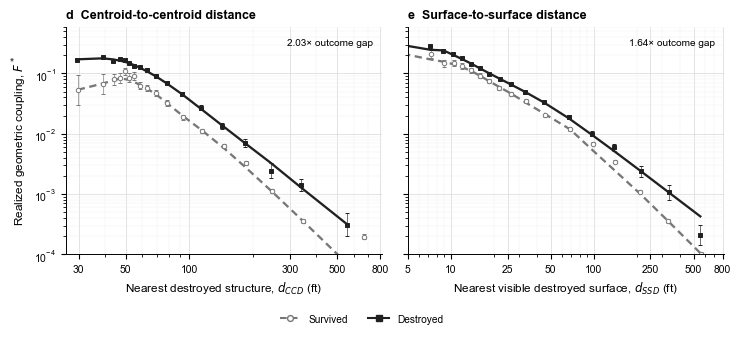

In [4]:
distance_data = prepare_distance_comparison(DATA, exposed)
distance_summaries = {
    measure: distance_outcome_summary(distance_data, measure)
    for measure in ['ccd_ft', 'ssd_ft']
}
distance_gap = pd.DataFrame([
    {'distance_measure': measure.replace('_ft', '').upper(),
     'destroyed_to_surviving_F_star_ratio': values[2]}
    for measure, values in distance_summaries.items()
])
distance_gap.to_csv(RESULTS / 'distance_outcome_gap.csv', index=False)
display(distance_gap.round(3))
plot_distance_comparison(distance_summaries, FIGURES, SOURCE_DATA);

## Destruction fragility

A five-parameter logistic curve is fitted separately by fire. $F_{50}$ is the exposure where the fitted probability is halfway between the lower and upper asymptotes; it is obtained by numerical inversion and is not generally the curve's location parameter or inflection point. Confidence intervals and the cross-fire ratio resample approximately 250-m spatial blocks separately within each fire.

,fire,outcome,n,p_min,p_max,k,hill,asymmetry,f50,f50_lo,f50_hi
0,EATON,destroyed,14595,0.02567,0.92745,0.02997,2.09208,0.68145,0.02284,0.02109,0.02411
1,PALISADES,destroyed,10532,0.05590,0.96034,0.10542,2.81487,0.21686,0.03437,0.02939,0.03892


Palisades:Eaton destruction F50 ratio = 1.505 (95% spatial-block CI 1.293–1.756; 200 successful draws)


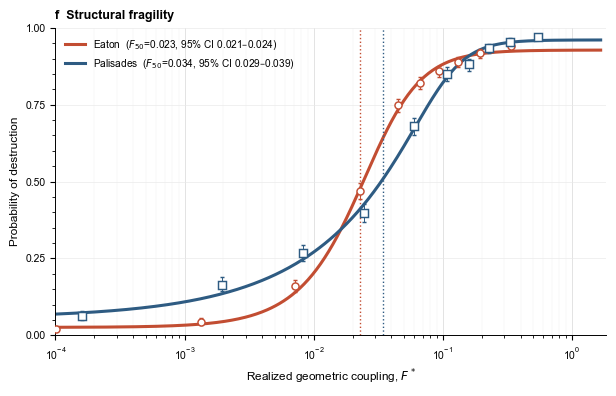

In [5]:
destroyed_fits, destroyed_parameters, destroyed_draws = fit_curves_by_fire(
    analysis, 'is_destroyed', n_boot=N_BOOT, seed=SEED
)
destroyed_parameters['outcome'] = 'destroyed'
destroyed_ratio = destroyed_fits['PALISADES']['f50'] / destroyed_fits['EATON']['f50']
destroyed_ratio_ci = np.percentile(destroyed_draws.ratio_PAL_to_EAT, [2.5, 97.5])
display(destroyed_parameters.round(5))
print(
    f'Palisades:Eaton destruction F50 ratio = {destroyed_ratio:.3f} '
    f'(95% spatial-block CI {destroyed_ratio_ci[0]:.3f}–{destroyed_ratio_ci[1]:.3f}; '
    f'{len(destroyed_draws)} successful draws)'
)
plot_fragility(analysis, destroyed_fits, FIGURES, SOURCE_DATA);

## Damage onset and escalation

The any-damage curve treats partial damage and destruction as one outcome. Subtracting the destruction curve estimates the fitted probability of partial damage at each exposure and locates the transition region where damage has begun but has not yet escalated to total loss.

,fire,outcome,n,p_min,p_max,k,hill,asymmetry,f50,f50_lo,f50_hi
0,EATON,any_damage,14595,0.04802,0.96757,0.03352,2.42179,0.42422,0.01867,0.01718,0.02004
1,PALISADES,any_damage,10532,0.07561,0.98612,0.08733,3.09648,0.14615,0.01893,0.01530,0.02303


,fire,peak_partial_probability,peak_F_star
0,EATON,0.11200,0.01692
1,PALISADES,0.16098,0.02758


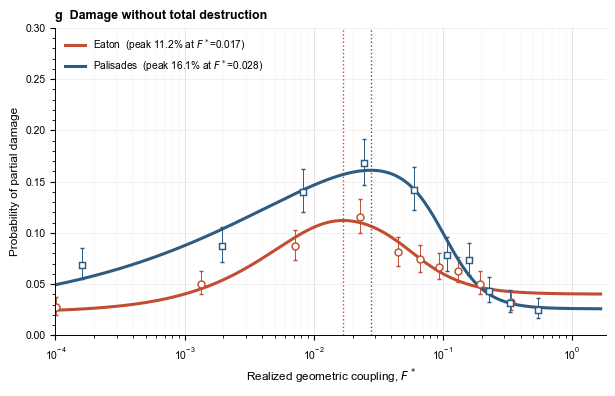

In [6]:
any_fits, any_parameters, any_draws = fit_curves_by_fire(
    analysis, 'any_damage', n_boot=N_BOOT, seed=SEED
)
any_parameters['outcome'] = 'any_damage'
partial_peaks = partial_damage_summary(
    destroyed_fits, any_fits, x_min=exposed.F_destroyed_wmean.min(),
    x_max=exposed.F_destroyed_wmean.max(),
)
partial_peaks.to_csv(RESULTS / 'partial_damage_summary.csv', index=False)
display(any_parameters.round(5))
display(partial_peaks.round(5))
plot_partial_damage(analysis, destroyed_fits, any_fits, partial_peaks,
                    FIGURES, SOURCE_DATA);

## Equivalent surface-to-surface distance

For a common physical interpretation, one pooled log–log relationship is fitted between $F^*$ and distance to the nearest visible destroyed surface. Its inverse expresses each $F_{50}$ as the SSD of one equivalently coupled burning structure. This is an interpretive equivalent because observed $F^*$ may aggregate several emitters.

In [7]:
calibration = fit_distance_calibration(distance_data)
all_parameters = pd.concat(
    [destroyed_parameters, any_parameters], ignore_index=True
)
equivalence = distance_equivalence_table(all_parameters, calibration)
equivalence.to_csv(RESULTS / 'f50_distance_equivalence.csv', index=False)
(RESULTS / 'pooled_distance_calibration.json').write_text(
    json.dumps(calibration, indent=2) + '\n'
)
display(pd.DataFrame([calibration]).round(4))
display(equivalence.round(3))
destroyed_distance = equivalence[equivalence.outcome.eq('destroyed')].set_index('fire')
distance_difference = (
    destroyed_distance.loc['EATON', 'equivalent_ssd_ft']
    - destroyed_distance.loc['PALISADES', 'equivalent_ssd_ft']
)
print(f'Common-calibration destruction-threshold difference: {distance_difference:.1f} ft')

,intercept,slope,r_squared,residual_sd,n
0,0.3501,-1.673,0.8526,0.9469,25127


,fire,outcome,f50,f50_lo,f50_hi,equivalent_ssd_ft,equivalent_ssd_lo_ft,equivalent_ssd_hi_ft,equivalent_ssd_m
0,EATON,destroyed,0.023,0.021,0.024,38.721,37.487,40.605,11.802
1,PALISADES,destroyed,0.034,0.029,0.039,30.326,28.157,33.303,9.243
2,EATON,any_damage,0.019,0.017,0.020,43.677,41.869,45.904,13.313
3,PALISADES,any_damage,0.019,0.015,0.023,43.315,38.524,49.191,13.202


Common-calibration destruction-threshold difference: 8.4 ft


## Freeze Figure 1 estimates and source data

In [8]:
all_parameters.to_csv(RESULTS / 'fragility_parameters.csv', index=False)
pd.concat([destroyed_draws, any_draws], ignore_index=True).to_csv(
    RESULTS / 'fragility_spatial_bootstrap_draws.csv', index=False
)
ratio_rows = []
for outcome, fits, draws in [
    ('destroyed', destroyed_fits, destroyed_draws),
    ('any_damage', any_fits, any_draws),
]:
    ratio = fits['PALISADES']['f50'] / fits['EATON']['f50']
    lo, hi = np.percentile(draws.ratio_PAL_to_EAT, [2.5, 97.5])
    ratio_rows.append({'outcome': outcome, 'ratio_PAL_to_EAT': ratio,
                       'ci_lo': lo, 'ci_hi': hi,
                       'successful_draws': len(draws)})
cross_fire = pd.DataFrame(ratio_rows)
cross_fire.to_csv(RESULTS / 'f50_cross_fire.csv', index=False)
display(cross_fire.round(4))
print('Figure files:', FIGURES)
print('Source-data files:', SOURCE_DATA)
print('Result tables:', RESULTS)

,outcome,ratio_PAL_to_EAT,ci_lo,ci_hi,successful_draws
0,destroyed,1.5051,1.2931,1.7562,200
1,any_damage,1.0140,0.8141,1.2266,200


Figure files: /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/main
Source-data files: /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/data/derived
Result tables: /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/results


## Assemble Main Figure 1

The final journal-width composite combines the conceptual comparison and frozen analytic source data. This rendering step does not refit any model.

In [9]:
# The quantitative component panels above are regenerated from packaged data.
# Restore the submitted composite, which incorporates the frozen architectural
# illustration without requiring the licensed scene mesh or patch-level LOS table.
for suffix in ['.png', '.pdf']:
    source = ASSETS / f'Fig1_geometric_coupling_and_fragility{suffix}'
    assert source.exists(), source
    shutil.copy2(source, FIGURES / source.name)
print('Main Figure 1:', FIGURES / 'Fig1_geometric_coupling_and_fragility.pdf')

Main Figure 1: /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/main/Fig1_geometric_coupling_and_fragility.pdf


## Interpretation

The distance panels test whether geometric coupling retains information after conventional separation is held approximately constant. The fragility curves then estimate the amount of realized coupling associated with structural loss. Comparing any-damage and destruction responses separates the onset of damage from escalation to total destruction.